# 5. Scenario Results and Discussion

This notebook is the final step in the thesis story. The previous notebook showed how the TDMA scheduler selects one minimum-power joint schedule for a single bin. Here I apply that same scheduler across the full day-cycle simulation and study the system-level result.

The structure is simple. First, I define the compared scenarios and the assumptions that stay fixed. Then I show the main day-level outputs. After that, I interpret what these results tell us about PA choice, power use, and frame pressure across the day.


In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), Path.cwd().parent)
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists()
    ),
    Path.cwd(),
).resolve()
NOTEBOOK_ROOT = (PROJECT_ROOT / 'notebooks').resolve()
SRC_ROOT = (PROJECT_ROOT / 'src').resolve()
DOC_IMG_DIR = PROJECT_ROOT / 'img'
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

for path_candidate in (NOTEBOOK_ROOT, PROJECT_ROOT, SRC_ROOT):
    if str(path_candidate) not in sys.path:
        sys.path.insert(0, str(path_candidate))

from helpers.scenario_results_helpers import ScenarioResultsHelpers

helper = ScenarioResultsHelpers(theme="aalto_elec")

## 1. What was simulated

All three scenarios use the same day demand, the same user-generation process, the same single-user candidate evaluation, and the same TDMA scheduler. The only change is the within-bin PA rule. This makes the comparison direct: when the results differ, the difference comes from how each scenario allows the scheduler to use the 4W and 8W PA families.

The table below summarizes the compared cases. A solved quarter-hour bin is a bin for which the scheduler found a feasible joint allocation. Mean total power is the average total PA DC power over the day. Day energy is the corresponding 24-hour energy sum in Wh.


In [2]:
SCENARIO_SPECS = [
    {
        'key': 'baseline',
        'path': PROJECT_ROOT / 'results' / 'default_day_run_baseline_8w_only' / 'day_run_result.json',
        'label': 'Baseline (8W only)',
        'role': 'Baseline',
        'within_bin_rule': 'Only 8W rows are allowed in every solved bin.',
        'why_it_matters': 'This is the fixed high-power reference.',
    },
    {
        'key': 'switchable',
        'path': PROJECT_ROOT / 'results' / 'default_day_run_dual_switchable' / 'day_run_result.json',
        'label': 'Switchable middle case',
        'role': 'Middle case',
        'within_bin_rule': '4W and 8W rows may be mixed inside the same bin.',
        'why_it_matters': 'This keeps both PA sizes available without forcing a bin-wide commitment.',
    },
    {
        'key': 'optimized',
        'path': PROJECT_ROOT / 'results' / 'default_day_run_hard_off' / 'day_run_result.json',
        'label': 'Optimized hard-off case',
        'role': 'Optimized case',
        'within_bin_rule': 'Each solved bin must commit to either 4W or 8W.',
        'why_it_matters': 'This is the hard-off bin-level comparator.',
    },
]

artifacts = helper.build_artifacts(
    scenario_specs=SCENARIO_SPECS,
    burden_scenario_key='optimized',
)

display(
    helper.render_table(
        artifacts.scenario_story_table,
        formats={
            'Mean total power (W)': '{:.2f}',
            'Day energy (Wh)': '{:.2f}',
        },
        caption='Scenario definitions used in the day-run comparison',
    )
)

Scenario,Role,Within-bin rule,Why it matters,Mean total power (W),Day energy (Wh)
Baseline (8W only),Baseline,Only 8W rows are allowed in every solved bin.,This is the fixed high-power reference.,18.34,431.08
Switchable middle case,Middle case,4W and 8W rows may be mixed inside the same bin.,This keeps both PA sizes available without forcing a bin-wide commitment.,11.44,268.78
Optimized hard-off case,Optimized case,Each solved bin must commit to either 4W or 8W.,This is the hard-off bin-level comparator.,12.10,284.29


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\run_results_scenario_bin_modes.png


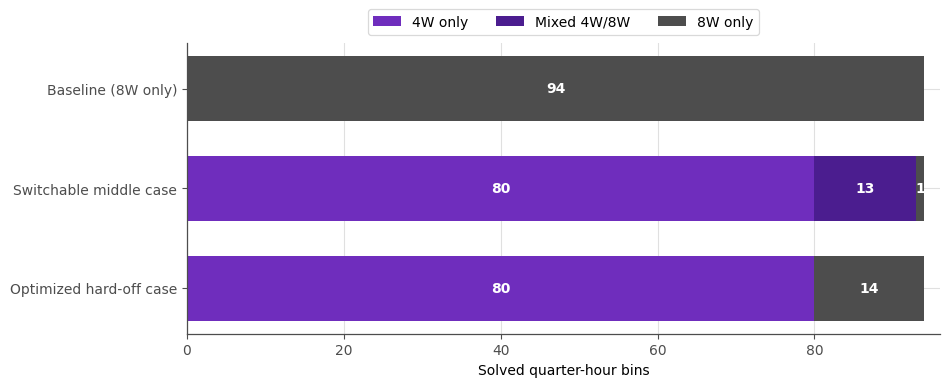

In [3]:
fig, ax = helper.plot_scenario_pa_modes(
    artifacts,
    export_path=DOC_IMG_DIR / 'run_results_scenario_bin_modes.png',
)
plt.show()

This figure shows how the solved quarter-hour bins are distributed by PA mode in each scenario. Read each horizontal bar from left to right: the segment lengths give the number of solved bins that ended in 4W-only operation, mixed 4W/8W operation, or 8W-only operation.

All three scenarios solve `94` quarter-hour bins in this run. The baseline solves all of them with the `8W` PA because that is the only allowed choice. The switchable case spreads solved bins across `4W`-only, mixed, and `8W`-only operation. The optimized hard-off case also uses both PA families across the day, but it does so by committing each solved bin to one family rather than mixing them inside the same bin. This makes the scenario logic visible before looking at power and energy.


## 2. What happens over the day

I now move from scenario definitions to the day-level outputs. The next plots show the total PA DC power in each quarter-hour bin and the cumulative day energy that follows from those bin values. Together they show both the local behavior of the scheduler and the full-day consequence.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\run_results_total_power_over_time.png


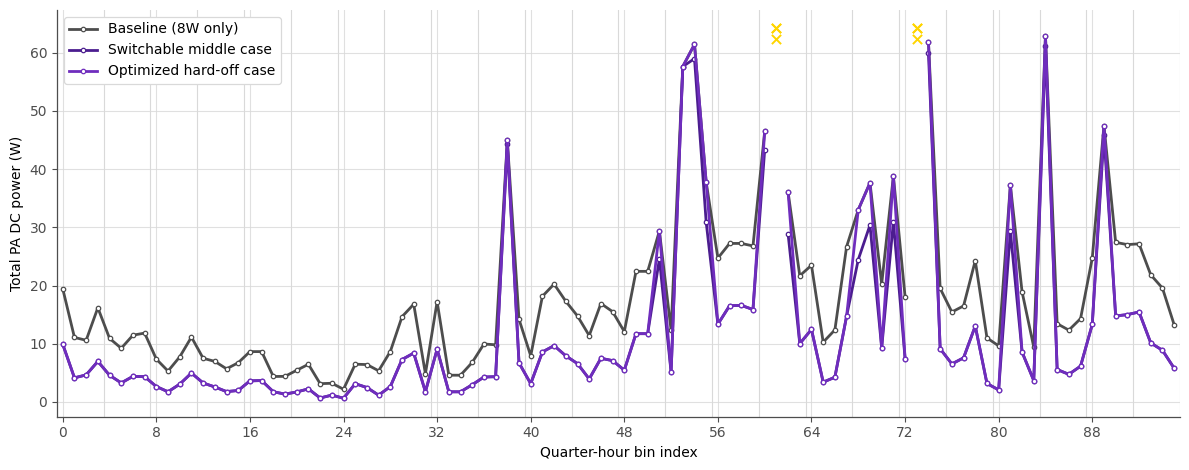

In [4]:
fig, ax = helper.plot_day_power_trajectories(
    artifacts,
    export_path=DOC_IMG_DIR / 'run_results_total_power_over_time.png',
)
plt.show()

This figure shows the total PA DC power for each quarter-hour bin. The x-axis is the bin index across the day, and the y-axis is the total PA DC power in watts for the joint schedule selected in that bin. Two bins did not have a feasible schedule in all three scenarios.

All three cases follow the same demand rhythm, but they do not pay the same power cost for it. The baseline remains the highest curve for most of the day. The two flexible cases stay well below it in many bins, which shows that allowing the scheduler to adapt the PA choice across the day reduces power substantially. In this run, the switchable middle case is usually slightly below the optimized hard-off case, which points to the value of keeping mixed `4W/8W` operation available inside a bin.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\run_results_cumulative_energy.png


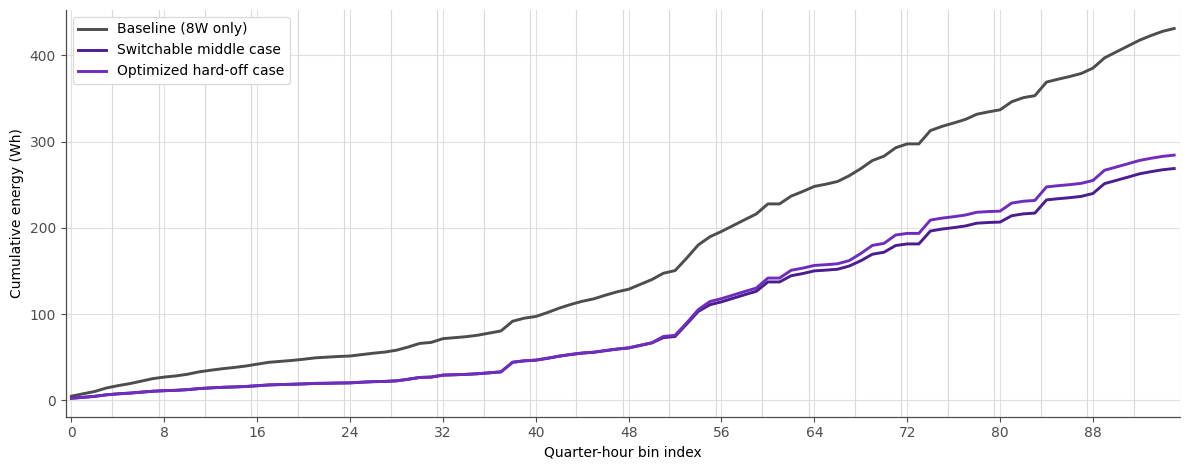

In [5]:
fig, ax = helper.plot_cumulative_day_energy(
    artifacts,
    export_path=DOC_IMG_DIR / 'run_results_cumulative_energy.png',
)
plt.show()

This figure accumulates the bin power results over the full day. Read it as the running energy total in Wh: steeper segments mark parts of the day where power is high, and flatter segments mark lighter periods.

The ordering is clear over the full horizon. The baseline ends with the largest day energy, at about `431.08 Wh`. The switchable middle case ends lowest, at about `268.78 Wh`, and the optimized hard-off case stays slightly above it, at about `284.29 Wh`. This means the same ranking seen in the bin-level power trace persists after integration over the whole day.


## 3. Results Discussion
The final plots do not just compare totals. They help explain why bins with similar overall demand can still land at different power levels and different PA choices. I focus on three views: total load versus power, burden shape from farther users, and used TDMA slots.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\run_results_load_vs_power.png


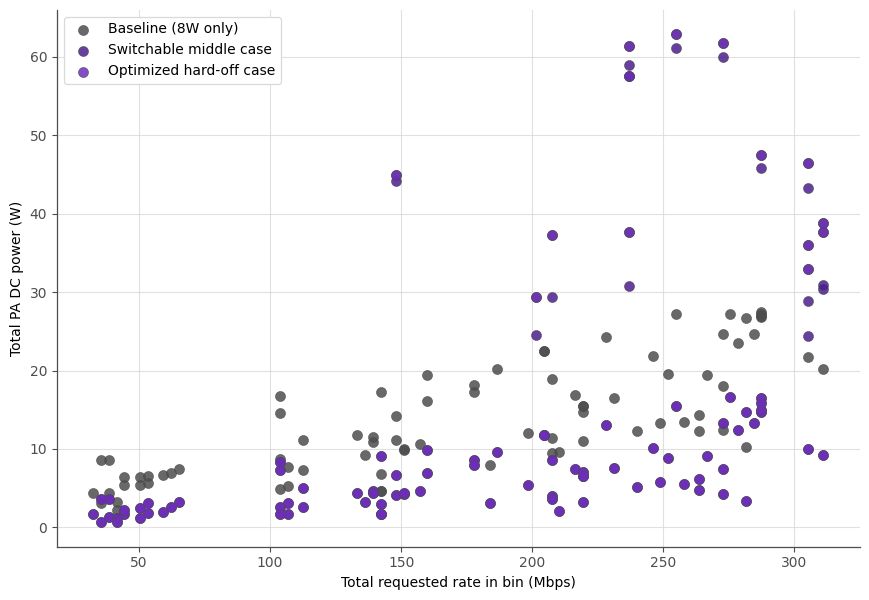

In [6]:
fig, ax = helper.plot_day_load_power_scatter(
    artifacts,
    export_path=DOC_IMG_DIR / 'run_results_load_vs_power.png',
)
plt.show()

This scatter plot compares total requested rate in a bin with the total PA DC power selected for that bin. The x-axis is the summed requested rate in Mbps, and the y-axis is the resulting total PA DC power in watts.

The main trend is positive: busier bins tend to use more power. But the spread is still wide, especially at moderate to high load. Bins with similar total requested rate can land at quite different power values. That means the bin total alone is not enough to explain the result. The user mix inside the bin still matters.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\run_results_hard_off_burden_shape.png


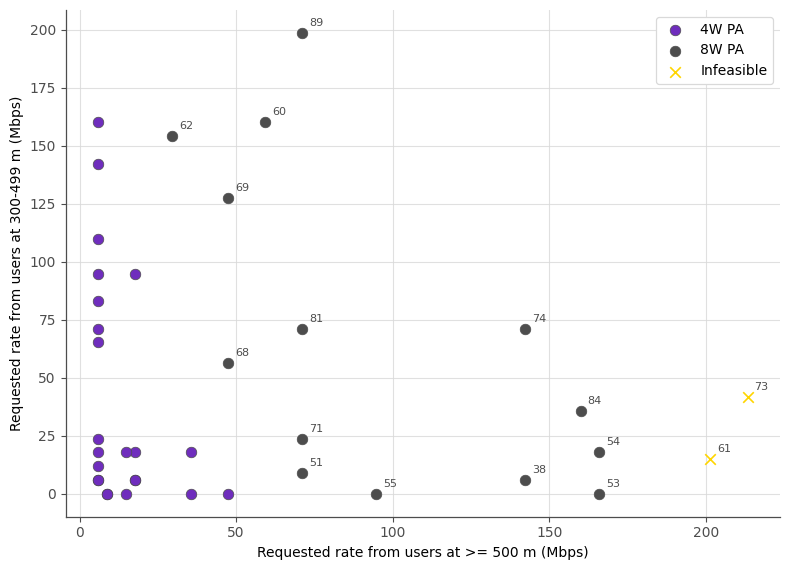

In [7]:
fig, ax = helper.plot_filtered_500m_total_burden_scatter(
    artifacts,
    export_path=DOC_IMG_DIR / 'run_results_hard_off_burden_shape.png',
)
plt.show()

This figure focuses on the optimized hard-off case and splits the bin demand by distance burden. The x-axis is the requested rate from users at `>= 500 m`, and the y-axis is the requested rate from users at `300-499 m`. Marker type and color show whether the bin was solved with the `4W` PA, solved with the `8W` PA, or left infeasible.

The key separation is along the far-user burden on the x-axis. As the demand from users at `>= 500 m` grows, bins move from `4W` operation toward `8W` operation and then toward infeasibility. The `300-499 m` burden still contributes, but it is a weaker separator. This shows that edge-of-cell demand is the main factor behind the hardest bins and the strongest power pressure in this model.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\run_results_used_slots_over_time.png


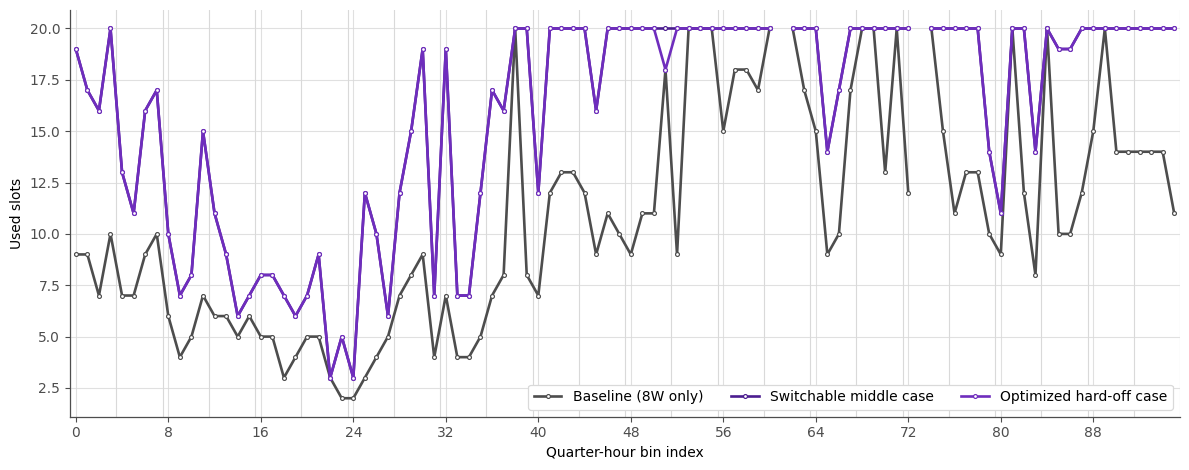

In [8]:
fig, ax = helper.plot_day_used_slots(
    artifacts,
    export_path=DOC_IMG_DIR / 'run_results_used_slots_over_time.png',
)
plt.show()

This figure shows how many of the `20` frame slots were used in each quarter-hour bin. Read it as frame pressure over the day: values near `20` indicate that the scheduler had little unused TDMA room left in that bin.

The busy parts of the day push the flexible cases close to full-slot use much more often than the baseline. That is important to read together with the earlier power plots. Higher slot use does not automatically mean higher PA power. In many bins the flexible cases use more of the frame but still consume less total PA DC power, because the scheduler trades time occupancy against a more efficient PA operating choice.


## 4. Main findings

This notebook applied the TDMA scheduler from the previous notebook across the full day-cycle simulation and compared three within-bin PA rules under the same demand.

The results show three clear points. First, fixing every solved bin to the `8W` PA gives the highest day-level power and energy. Second, allowing the scheduler to adapt PA use across bins reduces that cost substantially. Third, in this simulated day, the case that allows mixed `4W/8W` operation inside a bin finishes slightly below the hard-off bin-commitment case, which shows that extra within-bin flexibility can still matter after the single-bin optimization step.

Taken together, the day-level results support the original problem statement: PA energy use in 5G downlink scheduling depends not only on total load, but on how user demand, distance burden, and scheduler constraints interact inside each bin. The modeled scheduling approach uses that structure to reduce PA energy over the day.
